In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


# Project 2: Classification using Machine Learning Algorithms

## Student Performance Classification using Logistic Regression, Decision Tree and Random Forest

## Introduction

Machine Learning is used to analyze data and make predictions.

In this project, we classify student performance into two categories:
- Good Performance
- Poor Performance

We use the following algorithms:
- Logistic Regression
- Decision Tree
- Random Forest

The dataset contains student exam scores and related attributes.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv('/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv')

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## Data Visualization

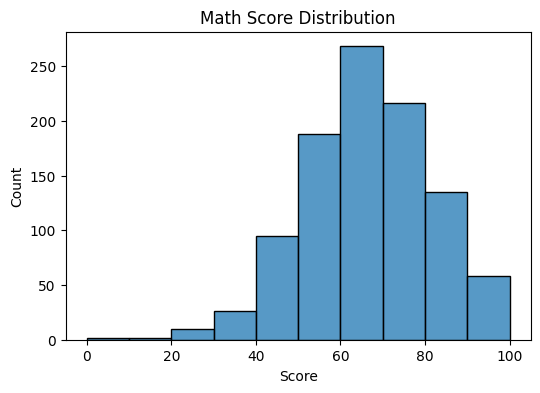

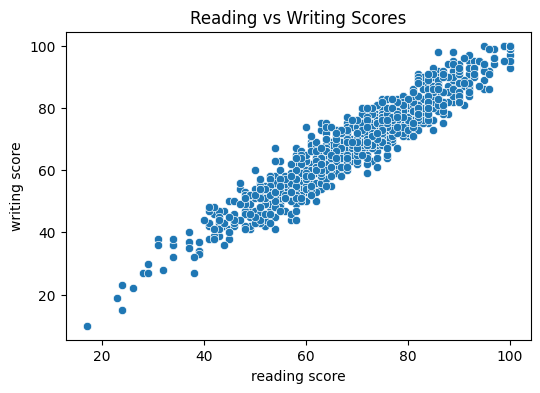

In [5]:
# Math score distribution
plt.figure(figsize=(6,4))
sns.histplot(df['math score'], bins=10)
plt.title("Math Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()

# Reading vs Writing
plt.figure(figsize=(6,4))
sns.scatterplot(x='reading score', y='writing score', data=df)
plt.title("Reading vs Writing Scores")
plt.show()

## Data Preprocessing

We convert the dataset into a classification problem:
- 1 → Good Performance
- 0 → Poor Performance

In [8]:
# Create target column
df['result'] = (df['math score'] > 60).astype(int)

# Clean text values
df['gender'] = df['gender'].astype(str).str.strip().str.lower()
df['test preparation course'] = df['test preparation course'].astype(str).str.strip().str.lower()

# Convert categories safely using replace
df['gender'] = df['gender'].replace({'male':0, 'female':1})
df['test preparation course'] = df['test preparation course'].replace({
    'none':0,
    'completed':1
})

# Force numeric (anything unexpected becomes NaN)
df['gender'] = pd.to_numeric(df['gender'], errors='coerce')
df['test preparation course'] = pd.to_numeric(df['test preparation course'], errors='coerce')

# Simple safe fill (no mode, no warnings)
df['gender'] = df['gender'].fillna(0)
df['test preparation course'] = df['test preparation course'].fillna(0)

# Check
print(df[['gender','test preparation course']].isnull().sum())

gender                     0
test preparation course    0
dtype: int64


## Feature Selection

In [9]:
X = df[['gender', 'reading score', 'writing score', 'test preparation course']]
y = df['result']

In [10]:
# Check missing values
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
result                         0
dtype: int64


In [12]:
# Fill missing values with 0 (simple fix)
df = df.fillna(0)

## Splitting the Dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training

In [14]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

## Model Predictions

In [16]:
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

## Performance Evaluation

In [17]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

print("\n--- Random Forest Report ---")
print(classification_report(y_test, rf_pred))

Logistic Regression Accuracy: 0.82
Decision Tree Accuracy: 0.74
Random Forest Accuracy: 0.775

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.71      0.66      0.69        74
           1       0.81      0.84      0.82       126

    accuracy                           0.78       200
   macro avg       0.76      0.75      0.76       200
weighted avg       0.77      0.78      0.77       200



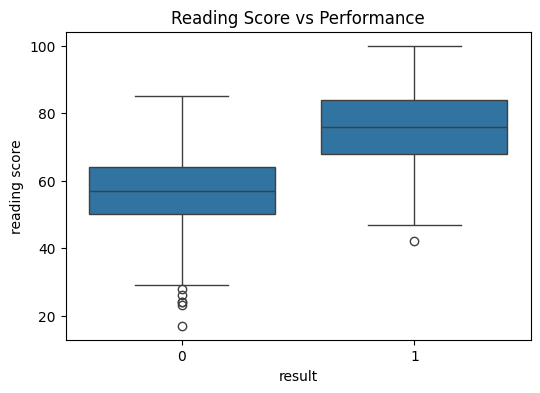

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='result', y='reading score', data=df)
plt.title("Reading Score vs Performance")
plt.show()

## Conclusion



In this project, student performance was classified using three machine learning algorithms.

*  Logistic Regression provided a baseline performance.
*  Decision Tree helped in understanding decision patterns.
*  Random Forest achieved the best accuracy among all models.

It was observed that students with higher reading and writing scores tend to perform better overall.